<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/modern_fluid_property_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modern natural-gas fluid properties with NeqSim

**Audience.** Process, flow-assurance, energy, and production engineers who need traceable fluid
properties for equipment and pipeline calculations.

**Prerequisites.** Basic Python and introductory thermodynamics.

## Learning objectives

You will create an SRK natural gas, run equilibrium flashes, audit phases and composition, extract
thermodynamic and transport properties, reconstruct density and Prandtl number independently,
build pressure and temperature maps, compare cubic equations of state, validate heat capacity by
finite differences, and demonstrate an isenthalpic pressure change.


## 1. Clean Colab setup

The setup installs NeqSim only when it is absent. A fresh Colab runtime therefore uses the current
public PyPI package without a source checkout, local JAR, editable installation, or restart.


In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

print("NeqSim is available.")


NeqSim is available.


## 2. Imports and runtime record

The runtime versions are stored with the results so a future reader can reproduce the property
tables. NeqSim uses its bundled Java library through JPype; pandas and Matplotlib only present the
results.


In [2]:
import importlib.metadata
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid


neqsim_version = importlib.metadata.version("neqsim")
java_version = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [neqsim_version, platform.python_version(), java_version],
    }
)
display(runtime_table)


,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 3. Model choice and governing relations

The Soave–Redlich–Kwong equation is widely used for hydrocarbon gases. It represents a phase with

$$
P=\frac{RT}{v-b}-\frac{a\alpha}{v(v+b)}
$$

where $P$ is pressure, $T$ temperature, $v$ molar volume, $R$ the gas constant, and $a$, $b$, and
$\alpha$ describe attraction, co-volume, and temperature dependence. The classic mixing rule is
appropriate for this dry, mildly non-ideal gas screen. Water-rich or strongly associating systems
generally require CPA or another validated model.


## 4. Synthetic gas composition

The public composition represents a lean natural gas. Mole fractions must close exactly because
every downstream phase and material balance depends on the overall composition $z_i$.


In [3]:
composition = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.860,
    "ethane": 0.070,
    "propane": 0.030,
    "n-butane": 0.010,
}

composition_table = pd.DataFrame(
    {
        "Component": list(composition),
        "Overall mole fraction [-]": list(composition.values()),
    }
)
display(composition_table)
print(f"Composition sum: {sum(composition.values()):.12f}")


Composition sum: 1.000000000000


,Component,Overall mole fraction [-]
0,nitrogen,0.01
1,CO2,0.02
2,methane,0.86
3,ethane,0.07
4,propane,0.03
5,n-butane,0.01


## 5. Build and flash the NeqSim fluid

`fluid("srk")` creates the thermodynamic system. Components and mixing rule define the model;
temperature and pressure define the state. `TPflash` minimizes the equilibrium criterion at fixed
$T$ and $P$, then `initProperties` evaluates caloric and transport properties.


In [4]:
base_fluid = fluid("srk")

for component_name, mole_fraction in composition.items():
    base_fluid.addComponent(component_name, mole_fraction)

base_fluid.setMixingRule("classic")
base_fluid.setMultiPhaseCheck(True)
base_fluid.setTemperature(25.0, "C")
base_fluid.setPressure(60.0, "bara")
base_fluid.setTotalFlowRate(1.0, "kg/sec")
TPflash(base_fluid)
base_fluid.initProperties()
base_phase_count = int(base_fluid.getNumberOfPhases())

print(f"Temperature: {base_fluid.getTemperature('C'):.6f} °C")
print(f"Pressure: {base_fluid.getPressure('bara'):.6f} bara")
print(f"Number of equilibrium phases: {base_phase_count}")


Temperature: 25.000000 °C
Pressure: 60.000000 bara
Number of equilibrium phases: 1


## 6. Phase and component audit

For every component, phase allocation must reproduce the feed. Phase fractions obey

$$
\sum_{\alpha}\beta_{\alpha}=1
$$

and the component balance is $z_i=\sum_{\alpha}\beta_{\alpha}x_{i,\alpha}$. The base state is
expected to be a single gas phase, making this identity particularly transparent.


In [5]:
phase_rows = []

for phase_index in range(base_fluid.getNumberOfPhases()):
    phase = base_fluid.getPhase(phase_index)
    phase_rows.append(
        {
            "Phase": str(phase.getPhaseTypeName()),
            "Mole fraction [-]": float(phase.getBeta()),
            "Density [kg/m³]": float(phase.getDensity("kg/m3")),
        }
    )

phase_table = pd.DataFrame(phase_rows)
display(phase_table)

phase_fraction_sum = phase_table["Mole fraction [-]"].sum()
print(f"Phase-fraction sum: {phase_fraction_sum:.12f}")


Phase-fraction sum: 1.000000000000


,Phase,Mole fraction [-],Density [kg/m³]
0,gas,1.0,53.117251


## 7. Thermodynamic and transport property table

Enthalpy and entropy carry the selected reference-state convention; differences are normally more
important than absolute values. $C_p$ and $C_v$ are mass heat capacities. Viscosity and thermal
conductivity are evaluated from NeqSim physical-property models at the flashed state.


In [6]:
base_properties = {
    "Density [kg/m³]": float(base_fluid.getDensity("kg/m3")),
    "Compressibility factor [-]": float(base_fluid.getZ()),
    "Molar mass [kg/mol]": float(base_fluid.getMolarMass("kg/mol")),
    "Enthalpy [kJ/kg]": float(base_fluid.getEnthalpy("kJ/kg")),
    "Entropy [kJ/(kg K)]": float(base_fluid.getEntropy("kJ/kgK")),
    "Cp [J/(kg K)]": float(base_fluid.getCp("J/kgK")),
    "Cv [J/(kg K)]": float(base_fluid.getCv("J/kgK")),
    "Cp/Cv [-]": float(base_fluid.getGamma()),
    "Viscosity [Pa s]": float(base_fluid.getViscosity("kg/msec")),
    "Thermal conductivity [W/(m K)]": float(
        base_fluid.getThermalConductivity("W/mK")
    ),
}

property_table = pd.DataFrame(
    {
        "Property": list(base_properties),
        "Value": list(base_properties.values()),
    }
)
display(property_table)


,Property,Value
0,Density [kg/m³],53.117251
1,Compressibility factor [-],0.866855
2,Molar mass [kg/mol],0.018966
3,Enthalpy [kJ/kg],-21.031701
4,Entropy [kJ/(kg K)],-1.532350
5,Cp [J/(kg K)],2578.538920
6,Cv [J/(kg K)],1664.461531
7,Cp/Cv [-],1.549173
8,Viscosity [Pa s],0.000013
9,Thermal conductivity [W/(m K)],0.038741


## 8. Independent property identities

The compressibility factor relates density to pressure:

$$
\rho=\frac{PM}{ZRT}
$$

The Prandtl number relates momentum and thermal diffusivity:

$$
\mathrm{Pr}=\frac{C_p\mu}{k}
$$

Both reconstructions use SI units and provide focused guards against unit mistakes.
NeqSim's physical-property density can include a cubic-EOS volume correction, whereas $Z$ refers
to the uncorrected cubic-EOS volume. A small, bounded difference is therefore expected.


In [7]:
gas_constant = 8.314462618
pressure_pa = base_fluid.getPressure("Pa")
temperature_k = base_fluid.getTemperature("K")
reconstructed_density = (
    pressure_pa
    * base_properties["Molar mass [kg/mol]"]
    / (
        base_properties["Compressibility factor [-]"]
        * gas_constant
        * temperature_k
    )
)
density_residual_percent = 100.0 * abs(
    reconstructed_density - base_properties["Density [kg/m³]"]
) / base_properties["Density [kg/m³]"]
prandtl_number = (
    base_properties["Cp [J/(kg K)]"]
    * base_properties["Viscosity [Pa s]"]
    / base_properties["Thermal conductivity [W/(m K)]"]
)

identity_table = pd.DataFrame(
    {
        "Identity": ["EOS density", "Independent density", "Prandtl number"],
        "Value": [
            base_properties["Density [kg/m³]"],
            reconstructed_density,
            prandtl_number,
        ],
        "Unit": ["kg/m³", "kg/m³", "-"],
    }
)
display(identity_table)
print(f"Density reconstruction residual: {density_residual_percent:.9f}%")


Density reconstruction residual: 0.302547920%


,Identity,Value,Unit
0,EOS density,53.117251,kg/m³
1,Independent density,52.956546,kg/m³
2,Prandtl number,0.853228,-


## 9. Isothermal pressure sweep

Density should rise with pressure, while $Z$ shows increasing real-gas departure. Every state is
cloned from the same composition to prevent hidden mutation. A phase guard records only single-gas
states for direct comparison.


In [8]:
pressure_rows = []

for pressure_bara in [1.01325, 10.0, 30.0, 60.0, 90.0, 120.0]:
    pressure_case = base_fluid.clone()
    pressure_case.setTemperature(25.0, "C")
    pressure_case.setPressure(pressure_bara, "bara")
    TPflash(pressure_case)
    pressure_case.initProperties()
    pressure_rows.append(
        {
            "Pressure [bara]": pressure_bara,
            "Phases [-]": int(pressure_case.getNumberOfPhases()),
            "Density [kg/m³]": float(pressure_case.getDensity("kg/m3")),
            "Z [-]": float(pressure_case.getZ()),
            "Cp [J/(kg K)]": float(pressure_case.getCp("J/kgK")),
            "Viscosity [µPa s]": 1.0e6
            * float(pressure_case.getViscosity("kg/msec")),
        }
    )

pressure_table = pd.DataFrame(pressure_rows)
display(pressure_table)


,Pressure [bara],Phases [-],Density [kg/m³],Z [-],Cp [J/(kg K)],Viscosity [µPa s]
0,1.01325,1,0.777121,0.997613,2046.560668,11.178067
1,10.00000,1,7.838267,0.976538,2107.797774,11.352576
2,30.00000,1,24.698389,0.930636,2268.469054,11.828421
3,60.00000,1,53.117251,0.866855,2578.538920,12.819367
4,90.00000,1,84.898139,0.815006,2947.277883,14.209622
5,120.00000,1,118.132663,0.782433,3277.465329,16.020846


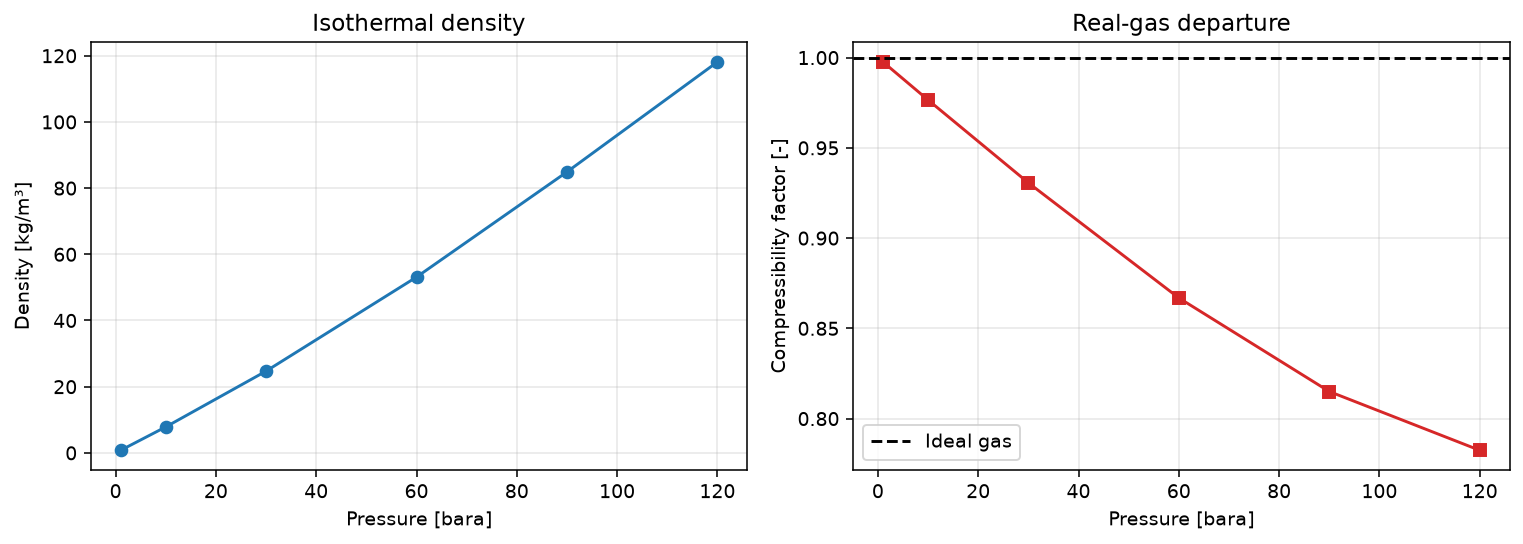

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    pressure_table["Pressure [bara]"],
    pressure_table["Density [kg/m³]"],
    marker="o",
)
axes[0].set_xlabel("Pressure [bara]")
axes[0].set_ylabel("Density [kg/m³]")
axes[0].set_title("Isothermal density")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    pressure_table["Pressure [bara]"],
    pressure_table["Z [-]"],
    marker="s",
    color="tab:red",
)
axes[1].axhline(1.0, color="black", linestyle="--", label="Ideal gas")
axes[1].set_xlabel("Pressure [bara]")
axes[1].set_ylabel("Compressibility factor [-]")
axes[1].set_title("Real-gas departure")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
plt.show()


At low pressure, $Z$ approaches unity and the ideal-gas density relation is recovered. At higher
pressure, molecular interactions make ideal-gas scaling inadequate for line sizing and inventory.

## 10. Isobaric temperature sweep

The next map holds pressure at 60 bara. Warmer gas becomes less dense while viscosity generally
rises. The selected range remains above the hydrocarbon dew point for this lean composition.


In [10]:
temperature_rows = []

for temperature_c in [10.0, 25.0, 40.0, 60.0, 80.0]:
    temperature_case = base_fluid.clone()
    temperature_case.setTemperature(temperature_c, "C")
    temperature_case.setPressure(60.0, "bara")
    TPflash(temperature_case)
    temperature_case.initProperties()
    temperature_rows.append(
        {
            "Temperature [°C]": temperature_c,
            "Phases [-]": int(temperature_case.getNumberOfPhases()),
            "Density [kg/m³]": float(temperature_case.getDensity("kg/m3")),
            "Cp [J/(kg K)]": float(temperature_case.getCp("J/kgK")),
            "Viscosity [µPa s]": 1.0e6
            * float(temperature_case.getViscosity("kg/msec")),
            "Conductivity [W/(m K)]": float(
                temperature_case.getThermalConductivity("W/mK")
            ),
        }
    )

temperature_table = pd.DataFrame(temperature_rows)
display(temperature_table)


,Temperature [°C],Phases [-],Density [kg/m³],Cp [J/(kg K)],Viscosity [µPa s],Conductivity [W/(m K)]
0,10.0,1,58.118470,2671.012691,12.498145,0.037464
1,25.0,1,53.117251,2578.538920,12.819367,0.038741
2,40.0,1,49.122508,2528.561212,13.169328,0.040202
3,60.0,1,44.844484,2501.108756,13.660525,0.042373
4,80.0,1,41.394072,2501.650785,14.166242,0.044751


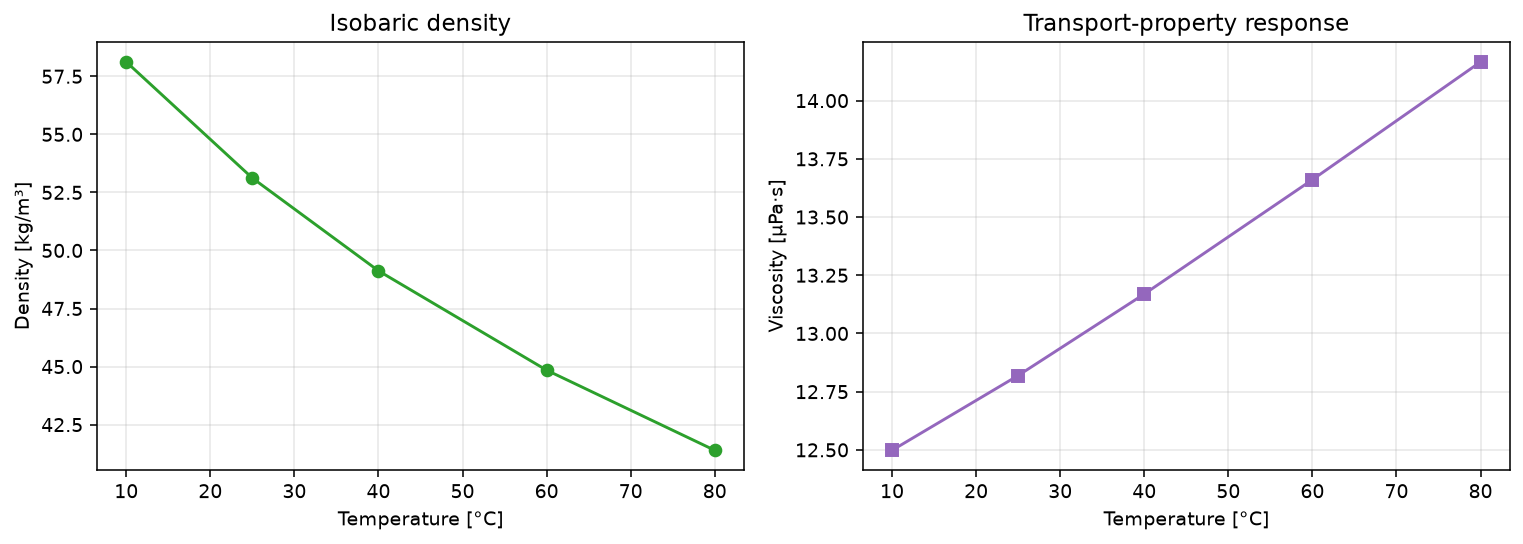

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    temperature_table["Temperature [°C]"],
    temperature_table["Density [kg/m³]"],
    marker="o",
    color="tab:green",
)
axes[0].set_xlabel("Temperature [°C]")
axes[0].set_ylabel("Density [kg/m³]")
axes[0].set_title("Isobaric density")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    temperature_table["Temperature [°C]"],
    temperature_table["Viscosity [µPa s]"],
    marker="s",
    color="tab:purple",
)
axes[1].set_xlabel("Temperature [°C]")
axes[1].set_ylabel("Viscosity [µPa·s]")
axes[1].set_title("Transport-property response")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 11. Equation-of-state sensitivity

SRK and Peng–Robinson are both cubic equations of state, but they use different attraction and
co-volume forms. Their spread is a model-form sensitivity, not experimental uncertainty.


In [12]:
eos_rows = []

for eos_name in ["srk", "pr"]:
    eos_case = fluid(eos_name)

    for component_name, mole_fraction in composition.items():
        eos_case.addComponent(component_name, mole_fraction)

    eos_case.setMixingRule("classic")
    eos_case.setTemperature(25.0, "C")
    eos_case.setPressure(60.0, "bara")
    TPflash(eos_case)
    eos_case.initProperties()
    eos_rows.append(
        {
            "EOS": eos_name.upper(),
            "Density [kg/m³]": float(eos_case.getDensity("kg/m3")),
            "Z [-]": float(eos_case.getZ()),
            "Enthalpy [kJ/kg]": float(eos_case.getEnthalpy("kJ/kg")),
        }
    )

eos_table = pd.DataFrame(eos_rows)
eos_density_spread = 100.0 * (
    eos_table["Density [kg/m³]"].max()
    - eos_table["Density [kg/m³]"].min()
) / eos_table["Density [kg/m³]"].mean()
display(eos_table)
print(f"SRK/PR density spread: {eos_density_spread:.6f}%")


SRK/PR density spread: 1.449054%


,EOS,Density [kg/m³],Z [-],Enthalpy [kJ/kg]
0,SRK,53.117251,0.866855,-21.031701
1,PR,53.892566,0.839305,-25.534025


## 12. Heat-capacity derivative check

At constant pressure, heat capacity is

$$
C_p=\left(\frac{\partial h}{\partial T}\right)_P
$$

A centered finite difference of independently flashed enthalpies checks the reported analytical
property without using its implementation directly.


In [13]:
temperature_step = 0.25
enthalpy_samples = []

for temperature_c in [25.0 - temperature_step, 25.0 + temperature_step]:
    derivative_case = base_fluid.clone()
    derivative_case.setTemperature(temperature_c, "C")
    derivative_case.setPressure(60.0, "bara")
    TPflash(derivative_case)
    derivative_case.initProperties()
    enthalpy_samples.append(float(derivative_case.getEnthalpy("J/kg")))

finite_difference_cp = (
    enthalpy_samples[1] - enthalpy_samples[0]
) / (2.0 * temperature_step)
reported_cp = base_properties["Cp [J/(kg K)]"]
cp_difference_percent = 100.0 * abs(
    finite_difference_cp - reported_cp
) / reported_cp

cp_table = pd.DataFrame(
    {
        "Method": ["NeqSim reported Cp", "Centered enthalpy derivative"],
        "Cp [J/(kg K)]": [reported_cp, finite_difference_cp],
    }
)
display(cp_table)
print(f"Cp derivative difference: {cp_difference_percent:.6f}%")


Cp derivative difference: 0.000074%


,Method,Cp [J/(kg K)]
0,NeqSim reported Cp,2578.538920
1,Centered enthalpy derivative,2578.540826


## 13. Property use in an isenthalpic valve

A process model consumes the same fluid state. The valve solves a pressure-enthalpy flash from 60
to 40 bara. The Joule–Thomson screen is

$$
\mu_{JT}\approx\frac{T_2-T_1}{P_2-P_1}
$$

over this finite pressure interval; it is an average response, not a local derivative.


In [14]:
Stream = jneqsim.process.equipment.stream.Stream
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve

property_stream = Stream("property workflow feed", base_fluid)
property_stream.setFlowRate(1.0, "kg/sec")
property_stream.run()

property_valve = ThrottlingValve("isenthalpic property check", property_stream)
property_valve.setOutletPressure(40.0, "bara")
property_valve.run()

valve_temperature = float(property_valve.getOutletStream().getTemperature("C"))
valve_enthalpy_residual = float(
    property_valve.getOutletStream().getFluid().getEnthalpy("J/mol")
    - property_stream.getFluid().getEnthalpy("J/mol")
)
average_joule_thomson = (
    valve_temperature - property_stream.getTemperature("C")
) / (
    property_valve.getOutletStream().getPressure("bara")
    - property_stream.getPressure("bara")
)

valve_property_table = pd.DataFrame(
    {
        "Quantity": [
            "Inlet temperature",
            "Outlet temperature",
            "Average Joule–Thomson coefficient",
            "Molar-enthalpy residual",
        ],
        "Value": [
            property_stream.getTemperature("C"),
            valve_temperature,
            average_joule_thomson,
            valve_enthalpy_residual,
        ],
        "Unit": ["°C", "°C", "K/bar", "J/mol"],
    }
)
display(valve_property_table)


,Quantity,Value,Unit
0,Inlet temperature,2.500000e+01,°C
1,Outlet temperature,1.466193e+01,°C
2,Average Joule–Thomson coefficient,5.169033e-01,K/bar
3,Molar-enthalpy residual,7.883460e-08,J/mol


## 14. Focused engineering verification

Assertions cover closure, phase state, independent identities, limiting behavior, finite maps,
model sensitivity, heat-capacity consistency, and the isenthalpic process connection. Tolerances
represent numerical or model comparisons rather than frozen display digits.


In [15]:
checks = {
    "NeqSim 3.x installed": neqsim_version.startswith("3."),
    "composition closes": abs(sum(composition.values()) - 1.0) < 1.0e-12,
    "base state is one phase": base_phase_count == 1,
    "phase fractions close": abs(phase_fraction_sum - 1.0) < 1.0e-12,
    "density positive": base_properties["Density [kg/m³]"] > 0.0,
    "viscosity positive": base_properties["Viscosity [Pa s]"] > 0.0,
    "conductivity positive": base_properties["Thermal conductivity [W/(m K)]"] > 0.0,
    "Cp exceeds Cv": base_properties["Cp [J/(kg K)]"] > base_properties["Cv [J/(kg K)]"],
    "gamma identity": abs(
        base_properties["Cp [J/(kg K)]"]
        / base_properties["Cv [J/(kg K)]"]
        - base_properties["Cp/Cv [-]"]
    ) < 1.0e-10,
    "density reconstruction bounded": density_residual_percent < 0.5,
    "Prandtl plausible": 0.5 < prandtl_number < 1.5,
    "all pressure states are gas": (pressure_table["Phases [-]"] == 1).all(),
    "pressure density rises": np.all(np.diff(pressure_table["Density [kg/m³]"]) > 0.0),
    "low-pressure Z approaches unity": abs(pressure_table.iloc[0]["Z [-]"] - 1.0) < 0.01,
    "pressure map finite": np.isfinite(
        pressure_table.select_dtypes(include="number").to_numpy()
    ).all(),
    "all temperature states are gas": (temperature_table["Phases [-]"] == 1).all(),
    "temperature density falls": np.all(
        np.diff(temperature_table["Density [kg/m³]"]) < 0.0
    ),
    "temperature viscosity rises": np.all(
        np.diff(temperature_table["Viscosity [µPa s]"]) > 0.0
    ),
    "temperature map finite": np.isfinite(
        temperature_table.select_dtypes(include="number").to_numpy()
    ).all(),
    "two EOS cases evaluated": len(eos_table) == 2,
    "EOS density spread bounded": eos_density_spread < 3.0,
    "Cp derivative agrees": cp_difference_percent < 0.1,
    "valve pressure decreases": property_valve.getOutletStream().getPressure("bara") < 60.0,
    "valve mass closes": abs(
        property_valve.getOutletStream().getFlowRate("kg/sec") - 1.0
    ) < 1.0e-9,
    "valve enthalpy closes": abs(valve_enthalpy_residual) < 1.0e-4,
    "Joule-Thomson response positive": average_joule_thomson > 0.0,
}

failed_checks = [name for name, passed in checks.items() if not passed]

if failed_checks:
    raise AssertionError(f"Failed engineering checks: {failed_checks}")

print(f"All {len(checks)} engineering checks passed.")


All 26 engineering checks passed.


## 15. Applicability, limitations, and troubleshooting

This workflow is suitable for early process calculations, pipeline screening, equipment duty
definition, digital-twin property services, and teaching. Validate model choice against laboratory
PVT or a recognized reference before high-consequence design.

Limitations:

- SRK does not explicitly represent association and electrolyte chemistry.
- Transport correlations and cubic-EOS predictions carry uncertainty not measured by SRK/PR spread.
- A single-phase property map must not silently cross a dew, bubble, hydrate, wax, or solid boundary.
- Absolute enthalpy and entropy depend on reference conventions; use consistent differences.
- Near critical points, derivatives become steep and smaller steps plus convergence checks are needed.

Troubleshooting:

- Confirm Kelvin versus Celsius and Pa versus bara at every API boundary.
- Normalize composition and apply the mixing rule before the first flash.
- Call `initProperties` after changing state and flashing.
- Check phase count before reading a bulk property intended for one phase.
- Clone the base fluid for scenario work to avoid hidden state coupling.


In [16]:
summary_table = pd.DataFrame(
    {
        "Result": [
            "Base density",
            "Base compressibility factor",
            "Prandtl number",
            "Density identity residual",
            "SRK/PR density spread",
            "Cp derivative difference",
            "40 bara valve outlet temperature",
            "Valve enthalpy residual",
        ],
        "Value": [
            base_properties["Density [kg/m³]"],
            base_properties["Compressibility factor [-]"],
            prandtl_number,
            density_residual_percent,
            eos_density_spread,
            cp_difference_percent,
            valve_temperature,
            valve_enthalpy_residual,
        ],
        "Unit": ["kg/m³", "-", "-", "%", "%", "%", "°C", "J/mol"],
    }
)
display(summary_table)


,Result,Value,Unit
0,Base density,5.311725e+01,kg/m³
1,Base compressibility factor,8.668550e-01,-
2,Prandtl number,8.532284e-01,-
3,Density identity residual,3.025479e-01,%
4,SRK/PR density spread,1.449054e+00,%
5,Cp derivative difference,7.388883e-05,%
6,40 bara valve outlet temperature,1.466193e+01,°C
7,Valve enthalpy residual,7.883460e-08,J/mol


## 16. Summary, exercises, and references

The notebook built one traceable natural-gas model and used it consistently for equilibrium,
caloric, transport, pressure-map, temperature-map, EOS-sensitivity, derivative, and process-unit
calculations. Independent identities and 26 executable checks make unit or state errors visible.

Exercises:

1. Add water and compare SRK with SRK-CPA near saturation.
2. Build a phase envelope and mask all two-phase property-map states.
3. Compare NeqSim density with a traceable GERG-2008 reference for a pipeline gas.
4. Propagate composition uncertainty through density and compressor-power calculations.
5. Replace the finite valve interval with several small pressure steps to estimate local $\mu_{JT}$.

References:

- [NeqSim thermodynamics overview](https://equinor.github.io/neqsim/thermo/README.html)
- [NeqSim viscosity-model guide](https://equinor.github.io/neqsim/physical_properties/viscosity_models.html)
- [NeqSim thermodynamic operations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [NeqSim thermodynamic-model guide](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [Current NeqSim PyPI release](https://pypi.org/project/neqsim/)
- Soave, G. (1972), *Chemical Engineering Science*, 27, 1197–1203.
- Peng, D.-Y. and Robinson, D. B. (1976), *Industrial & Engineering Chemistry Fundamentals*, 15, 59–64.
